In [ ]:
!pip3 install fasttext
import fasttext

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached pybind11-3.0.2-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.2-py3-none-any.whl (310 kB)
Failed to build fasttext


  error: subprocess-exited-with-error
  
  × Building wheel for fasttext (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [48 lines of output]
      C:\Users\sergi\AppData\Local\Temp\pip-build-env-4av4zzrz\overlay\Lib\site-packages\setuptools\dist.py:599: SetuptoolsDeprecationWarning: Invalid dash-separated key 'description-file' in 'metadata' (setup.cfg), please use the underscore name 'description_file' instead.
      !!
      
              ********************************************************************************
              Usage of dash-separated 'description-file' will not be supported in future
              versions. Please use the underscore name 'description_file' instead.
              (Affected: fasttext).
      
              Available configuration options are listed in:
              https://setuptools.pypa.io/en/latest/userguide/declarative_config.html
      
              This deprecation is overdue, please update your project and remove depre

ModuleNotFoundError: No module named 'fasttext'

In [10]:
!wget -c --no-check-certificate https://valencia.inf.um.es/valencia-plne/embeddings-s-model.bin.gz
!gzip -d embeddings-s-model.bin.gz

--2026-03-31 17:06:48--  https://valencia.inf.um.es/valencia-plne/embeddings-s-model.bin.gz
Resolving valencia.inf.um.es (valencia.inf.um.es)... 155.54.204.133
Connecting to valencia.inf.um.es (valencia.inf.um.es)|155.54.204.133|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 526737315 (502M) [application/x-gzip]
Saving to: ‘embeddings-s-model.bin.gz’

embeddings-s-model. 100%[===================>] 502.33M  31.1MB/s    in 17s     

2026-03-31 17:07:05 (30.1 MB/s) - ‘embeddings-s-model.bin.gz’ saved [526737315/526737315]



In [4]:
# Cargamos el modelo en binario usando la librería fasttext.
ft_model = fasttext.load_model ("embeddings-s-model.bin")

A continuación obtenemos la representación vectorial de la palabra "motomami" por ejemplo y de una palabra inventada como "aeiouaeiou"

In [5]:
vector = ft_model.get_word_vector("holalala")
#Mostramos las 6 primeras coordenadas
print(vector[:6])

vector = ft_model.get_word_vector("aeiouaeiou")
#Mostramos las 6 primeras coordenadas
print(vector[:6])

[ 0.39490592 -0.45491135  0.65146405  0.8123323   0.17195328 -0.3402024 ]
[-0.29263294 -0.29305226 -0.07346266  0.7548459   1.4783884  -0.5980789 ]


Podemos ver a continuación las subpalabras que se obtienen en fasttext dado una palabra dada y cuál sería el vector de cada subpalabra.

Podemos observar que el embedding de la palabra es la media de los vectores de las subpalabras.

In [ ]:
word = 'motomami'
# Obtener los n-gramas y sus índices
subwords, indices = ft_model.get_subwords(word)

# Obtener los vectores de cada n-grama
subword_vectors = {subword: ft_model.get_input_vector(idx) for subword, idx in zip(subwords, indices)}

# Mostrar los n-gramas y sus vectores
for subword, vector in subword_vectors.items():
    print(f"Subpalabra: {subword} -> Vector (primeros 5 valores): {vector[:5]}")

vectors_array = np.array(list(subword_vectors.values()))
subword_mean = np.mean(vectors_array, axis=0)

print(f"Palabra: {word} -> Vector (primeros 5 valores): {ft_model.get_word_vector(word)[:5]}")
print(f"Palabra: {word} -> Vector (primeros 5 valores): {subword_mean[:5]}")

Subpalabra: <mo -> Vector (primeros 5 valores): [ 0.4946093  -2.1682456   2.2707942   2.4833002   0.48527184]
Subpalabra: <mot -> Vector (primeros 5 valores): [-3.332991   0.8897533  1.4314964 -2.5178797 -1.3820633]
Subpalabra: <moto -> Vector (primeros 5 valores): [ 3.8935394  -0.9888346  -5.3031344   1.8848335   0.11568845]
Subpalabra: <motom -> Vector (primeros 5 valores): [ 1.1976271  -4.1768465   1.0979155  -4.397954    0.39417177]
Subpalabra: mot -> Vector (primeros 5 valores): [-1.6821992   3.4959261  -0.7129723   1.0603876   0.18844526]
Subpalabra: moto -> Vector (primeros 5 valores): [-1.1136621 -0.5231354 -6.575054   3.6364899 -2.1800737]
Subpalabra: motom -> Vector (primeros 5 valores): [-0.1988492  1.2042695  0.9610069  2.948558   4.584593 ]
Subpalabra: motoma -> Vector (primeros 5 valores): [ 1.1945434 -0.6909405 -3.6617255  4.894961  -3.1389072]
Subpalabra: oto -> Vector (primeros 5 valores): [-3.2760725   1.6481067  -2.2668462   1.615913    0.29050264]
Subpalabra: otom -

Podemos también calcular las palabras más similares a una dada.

In [ ]:
word = "madrid"

# Obtener las 10 palabras más similares
similar_words = ft_model.get_nearest_neighbors(word, k=10)

# Mostrar las palabras similares
print(f"Palabras similares a '{word}':")
for similarity, similar_word in similar_words:
    print(f"{similar_word} -> Similitud: {similarity:.4f}")

Palabras similares a 'madrid':
sevilla -> Similitud: 0.9594
bilbao -> Similitud: 0.9507
barcelona -> Similitud: 0.9494
málaga -> Similitud: 0.9415
valencia -> Similitud: 0.9366
gijón -> Similitud: 0.9356
alicante -> Similitud: 0.9270
coruña -> Similitud: 0.9267
vitoria -> Similitud: 0.9230
zaragoza -> Similitud: 0.9230


Sentence Embeddings con FastText

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
# Definimos un conjunto de textos
textos=['El procesamiento del lenguaje natural (PLN o NLP) es un campo dentro de la inteligencia artificial y la lingüística aplicada que estudia las interacciones mediante uso del lenguaje natural entre los seres humanos y las máquinas. \
Más concretamente se centra en el procesamiento de las comunicaciones humanas, dividiéndolas en partes, e identificando los elementos más relevantes del mensaje.\
Con la Comprensión y Generación de Lenguaje Natural, busca que las máquinas consigan entender, interpretar y manipular el lenguaje humano.'
, 'El procesamiento del lenguaje natural (NLP, por sus siglas en inglés) es una rama de la inteligencia artificial que ayuda a las computadoras a entender, interpretar y manipular el lenguaje humano. \
NLP toma elementos prestados de muchas disciplinas, incluyendo la ciencia de la computación y la lingüística computacional, en su afán por cerrar la brecha entre la comunicación humana y el entendimiento de las computadoras."""], """El procesamiento del lenguaje natural (PLN o NLP) es un campo dentro de la inteligencia artificial y la lingüística aplicada que estudia las interacciones mediante uso del lenguaje natural entre los seres humanos y las máquinas. Más concretamente se centra en el procesamiento de las comunicaciones humanas, dividiéndolas en partes, e identificando los elementos más relevantes del mensaje. Con la Comprensión y Generación de Lenguaje Natural, busca que las máquinas consigan entender, interpretar y manipular el lenguaje humano.'
, 'La lingüística computacional es un campo interdisciplinario que se ocupa del desarrollo de formalismos del funcionamiento del lenguaje natural, tales que puedan ser transformados en programas ejecutables para un ordenador. \
Dicho desarrollo se sitúa entre el modelado basado en reglas y el modelado estadístico del lenguaje natural desde una perspectiva computacional, y en él participan lingüistas e informáticos especializados en inteligencia artificial, psicólogos cognoscitivos y expertos en lógica, entre otros.'
, 'El aprendizaje automático es un tipo de inteligencia artificial (AI) que proporciona a las computadoras la capacidad de aprender, sin ser programadas explícitamente. El aprendizaje automático se centra en el desarrollo de programas informáticos que pueden cambiar cuando se exponen a nuevos datos.'
, 'El  aprendizaje profundo es un tema que cada vez adquiere mayor relevancia en el campo de la inteligencia artificial (IA). Siendo una subcategoría del aprendizaje automático, el aprendizaje profundo trata del uso de redes neuronales para mejorar cosas tales como el reconocimiento de voz, la visión por ordenador y el procesamiento del lenguaje natural. \
Rápidamente se está convirtiendo en uno de los campos más solicitados en informática. \
En los últimos años, el aprendizaje profundo ha ayudado a lograr avances en áreas tan diversas como la percepción de objetos, el procesamiento del lenguaje natural y el reconocimiento de voz (todas ellas áreas especialmente complejas para los investigadores en IA).',
'El coste de la energía va a subir mucho los próximos meses y la población va a tener que pagar cantidades excesivas a las eléctricas']


import pandas as pd
df_textos = pd.DataFrame(textos)

# Calculamos la similitud usando sentence embeddings
fasttext_sentence_embeddings = df_textos[0].apply(lambda x: ft_model.get_sentence_vector(x))
fasttext_sentence_embeddings = fasttext_sentence_embeddings.to_list()
import numpy as np

import scipy.sparse as sp
if not sp.issparse(fasttext_sentence_embeddings):
            fasttext_sentence_embeddings = sp.csr_matrix(fasttext_sentence_embeddings, dtype=np.float64)

# Calculamos la similitud del primer documento con el resto para sentence embeddings
results = cosine_similarity(fasttext_sentence_embeddings[1::],fasttext_sentence_embeddings[0]).reshape(-1,) # Op -- (n_docs,1) -- Cosine Sim with each doc
print(results)

[0.99586123 0.97653438 0.96497823 0.97840502 0.85345728]


Para este apartado se deben aplicar técnicas de similitud de documentos usando word embeddings 
de fastText para encontrar cuáles son los hilos más parecidos. La idea aquí es poder encontrar los hilos 
más parecidos entre sí, de acuerdo con los comentarios de cada hilo, y poder emplear herramientas 
de  visualización  para  poder  distinguir  cuáles  son  los  hilos  que  encajan  y  que  no  encajan  con  su 
subreddit. 

Para ello, se concatenarán todos los comentarios del mismo hilo y se obtendrá un sentence 
embedding por cada hilo y se podrán comparar usando medidas de similitud de vectores. 

Para  aprobar  este  apartado  se  utilizará  la  librería  de  fastText  vista  en  clase  para  la  obtención  de 
sentence embeddings. 

La puntuación base de este ejercicio es de 1 punto. Como tarea adicional, en este ejercicio se puntúa 
con 0,5 el uso de distintos modelos de sentence-transformers y hacer una comparación cualitativa de 
cuál funciona mejor.

In [1]:
import fasttext
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Cargamos el modelo en binario usando la librería fasttext.
ft_model = fasttext.load_model ("crawl-300d-2M-subword.bin")

Para poder comparar la similaridad entre hilos debemos de juntar todos los comentarios de cada hilo en un solo texto por hilo, y luego aplicar sentence embeddings para calcular la similaridad del coseno.

In [10]:
# 1. Cargar datos (ejemplo con un subreddit)
books = pd.read_json('ejemplo_subreddit_books.json')
display(books.head())

# 2. Extraer y concatenar comentarios por hilo
# Dependiendo de tu JSON, 'submissions' suele tener una lista de hilos
# y dentro de cada hilo una lista de 'comments'
def preparar_texto_hilo(row):
    hilo = row['submissions']
    # Extraemos título y descripción (si existen)
    titulo = str(hilo.get('title', ''))
    descripcion = str(hilo.get('description', ''))
    
    # Extraemos el cuerpo de todos los comentarios y los unimos
    comentarios = hilo.get('comments', [])
    texto_comentarios = " ".join([str(c.get('body', '')) for c in comentarios])
    
    # Devolvemos todo unido en un solo string
    return f"{titulo} {descripcion} {texto_comentarios}".strip()

# Creamos la columna con el texto completo del hilo
books['texto_completo'] = books.apply(preparar_texto_hilo, axis=1)

# Obtenemos el vector (sentence embedding) para cada hilo
books['embedding'] = books['texto_completo'].apply(lambda x: ft_model.get_sentence_vector(x.replace('\n', ' ')))

,subreddit,extraction_date,num_submissions,total_comments,submissions
0,books,2026-03-21T13:41:04.195764,70,2100,"{'author': 'cv5cv6', 'created_utc': 1735728185..."
1,books,2026-03-21T13:41:04.195764,70,2100,"{'author': 'FrancescoGozzo', 'created_utc': 17..."
2,books,2026-03-21T13:41:04.195764,70,2100,"{'author': 'EmpressPlotina', 'created_utc': 17..."
3,books,2026-03-21T13:41:04.195764,70,2100,"{'author': 'Hrmbee', 'created_utc': 1736032238..."
4,books,2026-03-21T13:41:04.195764,70,2100,"{'author': 'AutoModerator', 'created_utc': 173..."


In [11]:
books.head()

,subreddit,extraction_date,num_submissions,total_comments,submissions,texto_completo,embedding
0,books,2026-03-21T13:41:04.195764,70,2100,"{'author': 'cv5cv6', 'created_utc': 1735728185...",It’s Public Domain Day. Copyright has expired ...,"[-0.00060224324, -0.027183907, 0.06760837, 0.0..."
1,books,2026-03-21T13:41:04.195764,70,2100,"{'author': 'FrancescoGozzo', 'created_utc': 17...",What's a book you were looking forward to read...,"[0.0051493337, -0.012385359, 0.059575472, 0.00..."
2,books,2026-03-21T13:41:04.195764,70,2100,"{'author': 'EmpressPlotina', 'created_utc': 17...",What are authors that you almost enjoy [delet...,"[0.0058205733, -0.014793776, 0.06799245, 0.008..."
3,books,2026-03-21T13:41:04.195764,70,2100,"{'author': 'Hrmbee', 'created_utc': 1736032238...",A Book App Used AI to ‘Roast’ Its Users. It We...,"[0.0007774631, -0.013825375, 0.068087, 0.00748..."
4,books,2026-03-21T13:41:04.195764,70,2100,"{'author': 'AutoModerator', 'created_utc': 173...",What Books did You Start or Finish Reading thi...,"[-0.0002442529, -0.03240387, 0.026295405, 0.01..."


In [120]:
# Esto te daría una matriz de cuánto se parece cada hilo con todos los demás
matrices_similitud = cosine_similarity(list(books['embedding']))

<Axes: >

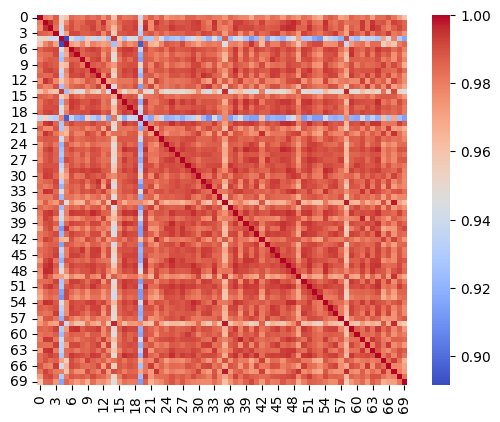

In [121]:
import seaborn as sns

sns.heatmap(matrices_similitud, annot=False, cmap='coolwarm', cbar=True, square=True)

Podemos observar en este mapa de calor que en este subreddit hay una gran similaridad entre hilos, sin embargo, se pueden distinguir tres hilos que se desvían un poco más de esta similaridad tan alta cerca de las lineas 3, 15 y 20, vamos a descubrir cuáles son exactamente.

In [122]:
# 1. Calculamos la media de similitud para cada fila (cada hilo)
# Restamos 1 porque la diagonal siempre es 1 (similitud consigo mismo)
mean_similarities = (matrices_similitud.sum(axis=1) - 1) / (matrices_similitud.shape[0] - 1)

# 2. Añadimos esta métrica a nuestro DataFrame original
books['similitud_media'] = mean_similarities

# 3. Ordenamos para ver los hilos MENOS similares al resto
hilos_intrusos = books.sort_values(by='similitud_media', ascending=True).head(3)

print("Hilos que menos encajan en el subreddit:")
print(hilos_intrusos[['texto_completo', 'similitud_media']])

Hilos que menos encajan en el subreddit:
                                       texto_completo  similitud_media
19  Name A book that you've read more than once  W...         0.932070
4   What Books did You Start or Finish Reading thi...         0.938331
14  What Books did You Start or Finish Reading thi...         0.958123


Descubrimos entonces que los 3 hilos que menos encajan en este subreddit son el 4, el 14 y el 19.

PCA

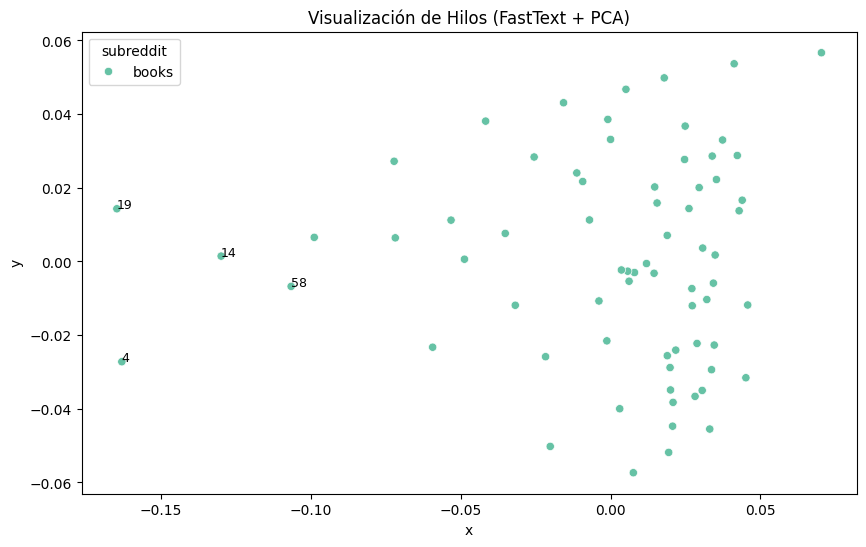

In [123]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Reducir dimensiones a 2D
pca = PCA(n_components=2)
puntos_2d = pca.fit_transform(list(books['embedding']))

# 2. Añadir al DataFrame para graficar
books['x'] = puntos_2d[:, 0]
books['y'] = puntos_2d[:, 1]

# 3. Graficar
plt.figure(figsize=(10, 6))
sns.scatterplot(data=books, x='x', y='y', hue='subreddit', palette='Set2')
plt.title("Visualización de Hilos (FastText + PCA)")

# Identificar los puntos más lejanos
for i in range(len(books)):
    if books['similitud_media'].iloc[i] < books['similitud_media'].quantile(0.05): # El 5% "peor"
        plt.text(books['x'].iloc[i], books['y'].iloc[i], str(i), fontsize=9)

COMPLETO

Procedemos ahora a hacerlo con todos los subreddits extraídos

In [56]:
import pandas as pd

archivos_json = [
    "ejemplo_subreddit_travel.json", 
    "ejemplo_subreddit_RandomThoughts.json", 
    "ejemplo_subreddit_unpopularopinion.json",
    "ejemplo_subreddit_jobs.json", 
    "ejemplo_subreddit_books.json", 
    "ejemplo_subreddit_LeagueOfLegends.json"
]

# Lista para ir guardando los dataframes temporales
lista_dfs = []

# 1. Cargar y consolidar
for archivo in archivos_json:
    temp_df = pd.read_json(archivo)
    lista_dfs.append(temp_df)

# Concatenamos todo en un solo DataFrame
df_total = pd.concat(lista_dfs, ignore_index=True)

# 2. Definir la función de preparación (incluimos limpieza de saltos de línea)
def preparar_texto_hilo(row):
    hilo = row['submissions']
    titulo = str(hilo.get('title', ''))
    descripcion = str(hilo.get('description', ''))
    
    comentarios = hilo.get('comments', [])
    # Unimos comentarios y limpiamos saltos de línea para evitar el ValueError de fastText
    texto_comentarios = " ".join([str(c.get('body', '')).replace('\n', ' ') for c in comentarios])
    
    return f"{titulo} {descripcion} {texto_comentarios}".strip().replace('\n', ' ')

# 3. Procesar texto y generar embeddings
print("Procesando textos...")
df_total['texto_completo'] = df_total.apply(preparar_texto_hilo, axis=1)

print("Generando embeddings con FastText...")
df_total['embedding'] = df_total['texto_completo'].apply(lambda x: ft_model.get_sentence_vector(x))

print(f"Completado. Total de hilos procesados: {len(df_total)}")
display(df_total[['subreddit', 'texto_completo', 'embedding']].head())

Procesando textos...
Generando embeddings con FastText...
Completado. Total de hilos procesados: 420


,subreddit,texto_completo,embedding
0,travel,HELP on deciding first trip out of the country...,"[0.0024686179, -0.022190968, 0.07993955, 0.007..."
1,travel,What's your favorite city that you traveled to...,"[0.0035470827, -0.019607686, 0.069118395, 0.00..."
2,travel,What is a country or place you’ve visited that...,"[0.0042783855, -0.012964662, 0.074817225, 0.01..."
3,travel,Busted by Corrupt Cops in Mexico City **Notic...,"[0.0005220581, -0.022751845, 0.08044942, 0.005..."
4,travel,More Americans should travel to third world co...,"[0.0008042359, -0.028552653, 0.08359149, 0.007..."


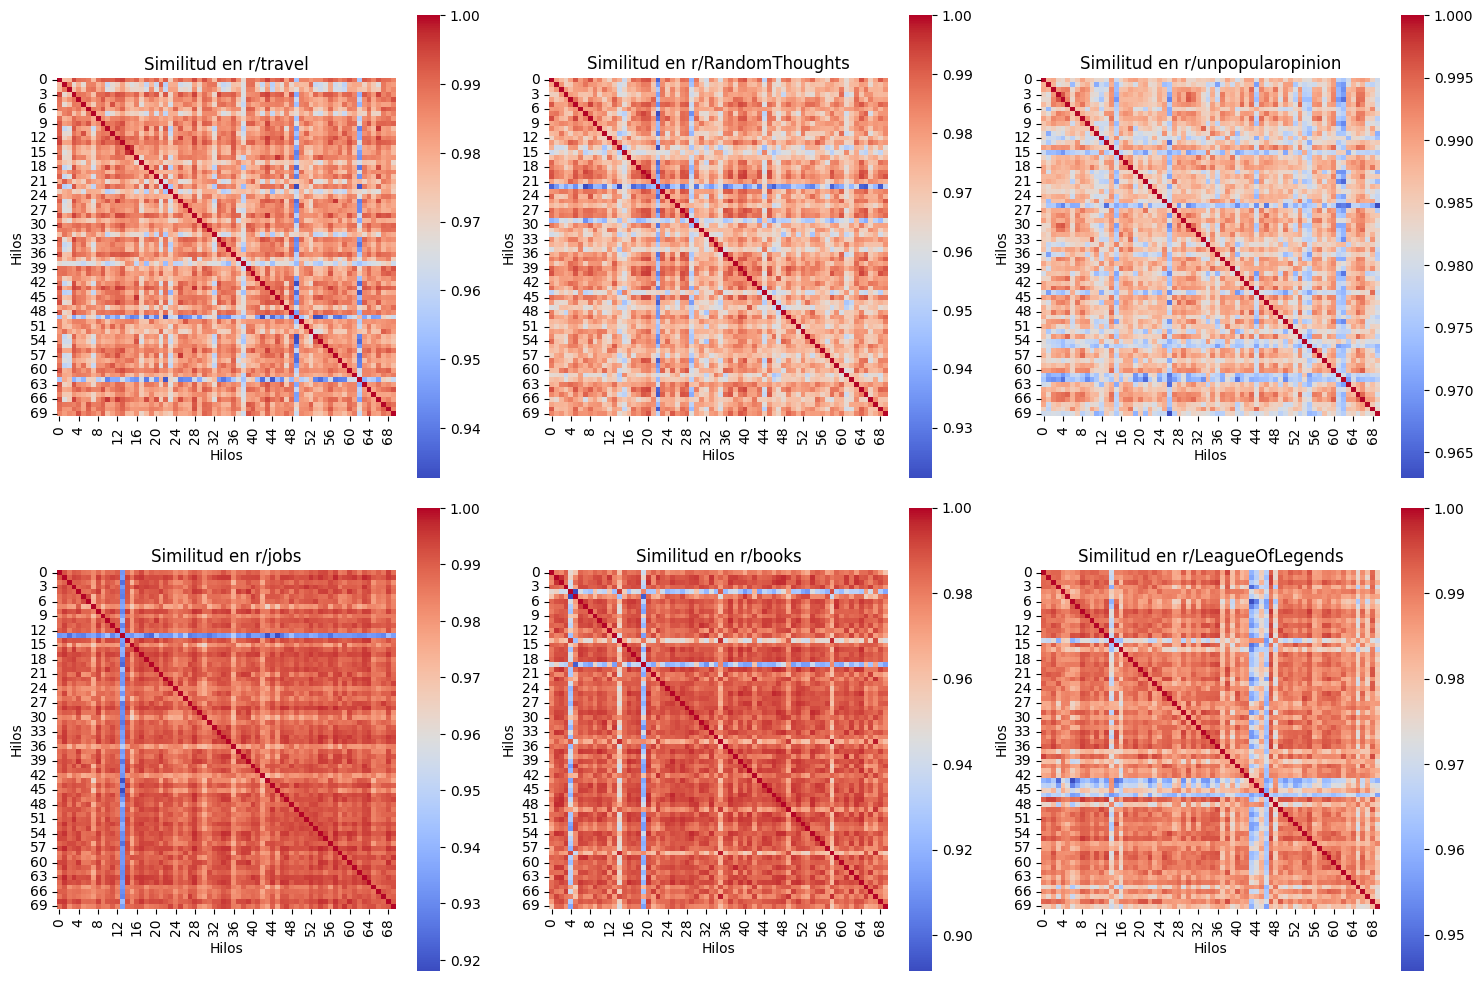

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# Obtenemos la lista de subreddits únicos
subreddits = df_total['subreddit'].unique()

ncols = 3
nrows = 2

# Preparamos la figura con subgráficos
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
axes = axes.flatten() # Aplanamos para iterar fácilmente

# Iteramos sobre cada subreddit para generar su propio heatmap
for i, sub in enumerate(subreddits):
    # 1. Filtramos los hilos que pertenecen solo a este subreddit
    df_sub = df_total[df_total['subreddit'] == sub]
    
    # 2. Calculamos la matriz de similitud solo para esos hilos
    similitud_sub = cosine_similarity(list(df_sub['embedding']))
    
	# Calculamos la similitud media para cada hilo dentro de su subreddit para hacer las próximas gráficas
    mean_similarities = (similitud_sub.sum(axis=1) - 1) / (similitud_sub.shape[0] - 1)
    
    df_total.loc[df_total['subreddit'] == sub, 'similitud_media'] = mean_similarities
    
    # 3. Dibujamos el heatmap en su 'hueco' correspondiente de la cuadrícula
    sns.heatmap(similitud_sub, annot=False, cmap='coolwarm', ax=axes[i], 
                cbar=True, square=True)
    
    # Retoques estéticos
    axes[i].set_title(f'Similitud en r/{sub}')
    axes[i].set_xlabel('Hilos')
    axes[i].set_ylabel('Hilos')

# Si sobran huecos en la cuadrícula (ej. tenemos 5 subreddits para 6 huecos), los ocultamos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

PCA

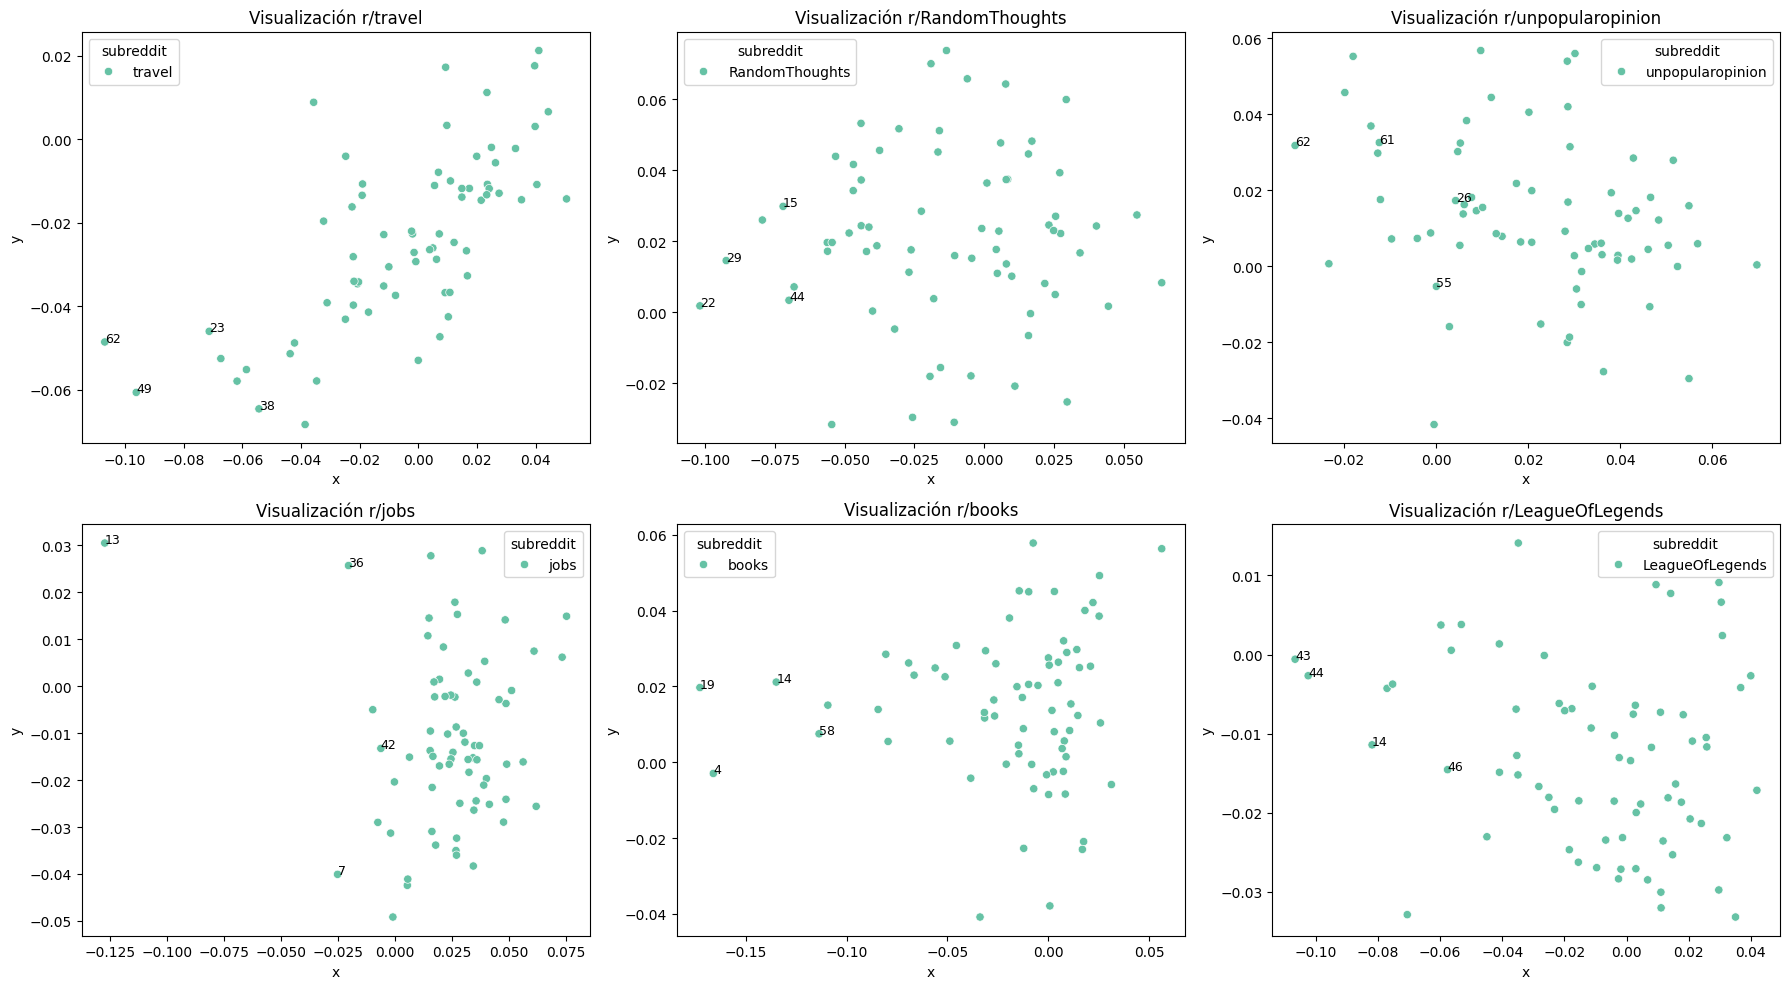

In [117]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Reducir dimensiones a 2D
pca = PCA(n_components=2)
puntos_2d = pca.fit_transform(list(df_total['embedding']))

# 2. Añadir al DataFrame para graficar
df_total['x'] = puntos_2d[:, 0]
df_total['y'] = puntos_2d[:, 1]

# 3. Preparar la cuadrícula de subgráficas
subreddits = df_total['subreddit'].unique()
ncols = 3
nrows = 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))
axes = axes.flatten() # Aplanamos para usar un solo índice (axes[i])

# 4. Dibujar una gráfica por cada subreddit
for i, sub in enumerate(subreddits):
    # Filtramos los datos solo para esta comunidad
    df_sub = df_total[df_total['subreddit'] == sub]
    
    # Dibujamos el scatterplot en el subgráfico correspondiente (ax=axes[i])
    sns.scatterplot(data=df_sub, x='x', y='y',hue='subreddit', palette='Set2', ax=axes[i])
    axes[i].set_title(f"Visualización r/{sub}")
    
    # Calculamos el 5% "peor" (menos similares) SOLO para este subreddit
    umbral_outliers = df_sub['similitud_media'].quantile(0.05)
    
    # Identificar y etiquetar los puntos más lejanos
    for idx, row in df_sub.iterrows():
        if row['similitud_media'] < umbral_outliers:
            # Ponemos el texto (usamos idx para que veas el índice original del DataFrame)
            axes[i].text(row['x'], row['y'], str(idx%70), fontsize=9, color='black')

# 5. Ocultar los subgráficos vacíos (por si tuvieras por ejemplo 5 subreddits en lugar de 6)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Podemos observar que aunque en general los outliers corresponden con los puntos más alejados de la representación del PCA, no ocurre en todos los casos, como se ve en **r/unpopularopinion** (el más notable), pues la similaridad del coseno media con los hilos de su subreddit se calcula con todas las dimensiones del embedding, y puede ser que al "aplastar" esas dimensiones en solo 2 para poder representarlas, la diferencia que se ha calculado anteriormente no coincida visualmente con estas dos primeras dimensiones representadas, por eso vemos que los hilos menos similares en r/unpopularopinion, "visualmente" no están alejados en esta representación 2D.